## Summary of Foul Prediction Model Evolution

This notebook demonstrates a comprehensive approach to analyzing foul events in football data. It starts with basic data extraction and visualization of foul locations, then progresses to building a predictive model that considers not only location but also game context (minute, pressure). The model effectively highlights the most probable areas for fouls and identifies the key factors influencing these probabilities. The interactive prediction tool allows for dynamic exploration of how different game scenarios impact foul likelihood across the pitch.

### 1. Data Loading and Initial Foul Identification
*   **Initial Data**: The `epl_event_data_15.csv` was loaded into `df_raw`, then processed into `df` with cleaned column names. This dataset contains a wide array of football event details.
*   **Foul Event Isolation**: The first step was to identify all rows containing the word 'foul'. This led to the creation of `fouls_df`, which contains 7,940 events where 'foul' was mentioned. The primary column for foul-related information was identified as `type.name` (e.g., 'Foul Committed', 'Foul Won').
*   **Top Players**: We identified top players involved in fouls using the `player.name` column from `fouls_df`, with Sadio Mané leading with 80 foul events.

### 2. Location Data Processing and Heatmaps
*   **Parsing Location**: The `location` column, initially a string, was parsed into numerical `x` and `y` coordinates. This created `foul_locations`, a DataFrame with valid coordinates for foul events.
*   **Specific Foul Types**: This `foul_locations` DataFrame was then split into `foul_committed_locations` (4,053 events) and `foul_won_locations` (3,887 events) to analyze each type separately.
*   **Visualizing Locations**: Initial heatmaps were generated for both 'Foul Committed' and 'Foul Won' events using these coordinates, showing their distribution across a simulated football field. This gave a visual sense of where these events tend to occur.

### 3. Basic Probability Maps (Grid-based)
*   **Discretization**: The field was divided into a grid (10x10 units per cell). The `x_bins` and `y_bins` arrays defined these divisions.
*   **Probability Calculation**: For both 'Foul Committed' (`probability_map`) and 'Foul Won' (`probability_map_won`), 2D histograms were created (`hist`, `hist_won`) and normalized by the total number of respective events. This gave us a probability of a foul occurring in each grid cell based purely on location.
*   **Side-by-Side Comparison**: These basic probability maps were displayed side-by-side to allow for a direct visual comparison of where 'Foul Committed' and 'Foul Won' events are more likely.

### 4. Optimized Predictive Model: Incorporating Pressure and Time
*   **Dataset Balancing**: To build a robust predictive model, a balanced dataset (`model_df`) was crucial. This was achieved by taking all 'Foul Committed' events and sampling an equal number of *non-foul* events from the original `df`. `is_foul_committed` was added as the binary target variable (1 for foul, 0 for non-foul).
*   **Feature Selection**: The model utilized the features `x`, `y`, `minute`, `under_pressure`, and `counterpress` from the `model_df`. Missing values in `minute`, `under_pressure`, and `counterpress` were handled (e.g., filled with 0 or median).
*   **Model Training**: A `RandomForestClassifier` was trained on this balanced dataset.
*   **Model Evaluation**: The model achieved an **Accuracy of approximately 0.63** and an **ROC AUC of about 0.73**, indicating a reasonable ability to distinguish between foul and non-foul events. The **ROC AUC score (0.7274)** measures the model's ability to discriminate between positive and negative classes across various threshold settings, with a higher value indicating better performance. A **confusion matrix** was used to further evaluate the model's performance:
    *   **True Negatives (Non-Foul correctly predicted):** 759
    *   **False Positives (Non-Foul incorrectly predicted as Foul):** 457
    *   **False Negatives (Foul incorrectly predicted as Non-Foul):** 444
    *   **True Positives (Foul correctly predicted):** 772
    This breakdown helps in understanding the types of errors the model is making.
*   **Initial Prediction Visualization**: A prediction grid (`grid_predictions_input`) was created to cover the entire field. The model then predicted the probability of a foul at each point on this grid, initially assuming *average* values for `minute`, `under_pressure`, and `counterpress`. This resulted in a heatmap showing the predicted foul probabilities across the field under an average scenario.

### 5. Feature Importance Analysis
*   **Key Drivers**: An analysis of the `model`'s `feature_importances_` was performed, resulting in `feature_importance_df`. The **'y' coordinate (0.3087)** and **'x' coordinate (0.3046)** were identified as the most important features, followed by **'minute' (0.2079)**. `under_pressure` and `counterpress` also contributed, but to a lesser extent.

### 6. Interactive Probability Prediction
*   **Dynamic Scenario Exploration**: To allow for more flexible analysis, interactive widgets (`minute_slider`, `under_pressure_toggle`, `counterpress_toggle`) were introduced. These widgets dynamically update the prediction heatmap based on user-defined values for `minute`, `under_pressure`, and `counterpress`, enabling interactive scenario testing of foul probabilities across the field.

### Consolidated Model 1 Code for GitHub

This section consolidates all the code for Model 1, from data loading and processing to model training, evaluation, and prediction visualization, into a single, sequential flow. Interactive widgets have been removed for a static, reproducible script.

In [16]:
# --- All necessary Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import ast
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# --- 1. Data Loading and Initial Foul Identification ---
file_id = "10Pt7oGjccLN9ko6O_YSlwxNHE8dbn2pU"
downloaded_filename = 'epl_event_data_15.zip'
unzipped_filename = 'epl_event_data_15.csv'

# Download the file using gdown
!gdown --id {file_id} --output {downloaded_filename}

# Check if the downloaded file is a zip file and extract it
if zipfile.is_zipfile(downloaded_filename):
    with zipfile.ZipFile(downloaded_filename, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to current directory
    print(f"Extracted {unzipped_filename} from {downloaded_filename}")
else:
    os.rename(downloaded_filename, unzipped_filename)

df_raw = pd.read_csv(unzipped_filename, on_bad_lines='skip', encoding='latin1', engine='python')
df_raw.columns = [str(col).replace('"', '').strip() for col in df_raw.columns]

# Assuming df_raw is available, create fouls_df
string_columns_raw = df_raw.select_dtypes(include='object').columns
foul_mask = df_raw[string_columns_raw].apply(lambda col: col.astype(str).str.contains('foul', case=False, na=False)).any(axis=1)
fouls_df = df_raw[foul_mask].copy()

# Function to safely parse location strings into lists
def parse_location(loc_str):
    try:
        return ast.literal_eval(loc_str)
    except (ValueError, SyntaxError):
        return None

fouls_df['parsed_location'] = fouls_df['location'].astype(str).apply(parse_location)
foul_locations = fouls_df[fouls_df['parsed_location'].notna() & \
                          fouls_df['parsed_location'].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 2)].copy()
foul_locations['x'] = foul_locations['parsed_location'].apply(lambda loc: loc[0])
foul_locations['y'] = foul_locations['parsed_location'].apply(lambda loc: loc[1])

foul_committed_locations = foul_locations[foul_locations['type.name'] == 'Foul Committed'].copy()


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=10Pt7oGjccLN9ko6O_YSlwxNHE8dbn2pU
From (redirected): https://drive.google.com/uc?id=10Pt7oGjccLN9ko6O_YSlwxNHE8dbn2pU&confirm=t&uuid=2cf35ae2-0e44-47bf-8727-fc371fc9f89e
To: /content/epl_event_data_15.zip
100% 83.1M/83.1M [00:00<00:00, 131MB/s]
Extracted epl_event_data_15.csv from epl_event_data_15.zip


### Model 1: Optimized Predictive Model - Training and Evaluation


--- Model 1 Performance ---
Accuracy: 0.6545
ROC AUC: 0.7385

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.64      0.65      2854
           1       0.65      0.67      0.66      2854

    accuracy                           0.65      5708
   macro avg       0.65      0.65      0.65      5708
weighted avg       0.65      0.65      0.65      5708



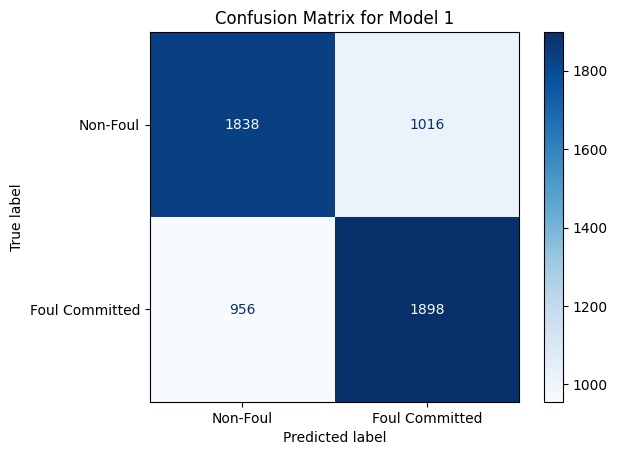

Confusion Matrix Breakdown:
True Negatives (Non-Foul correctly predicted): 1838
False Positives (Non-Foul incorrectly predicted as Foul): 1016
False Negatives (Foul incorrectly predicted as Non-Foul): 956
True Positives (Foul correctly predicted): 1898


In [19]:
# --- Feature Engineering for Model 1 ---
# 1. Prepare Foul Committed events (target = 1)
foul_committed_data = foul_committed_locations.copy()
foul_committed_data['is_foul_committed'] = 1

if 'under_pressure' in foul_committed_data.columns:
    foul_committed_data['under_pressure'] = foul_committed_data['under_pressure'].fillna(0).astype(int)
else:
    foul_committed_data['under_pressure'] = 0

if 'counterpress' in foul_committed_data.columns:
    foul_committed_data['counterpress'] = foul_committed_data['counterpress'].fillna(0).astype(int)
else:
    foul_committed_data['counterpress'] = 0

# 2. Prepare Non-Foul events (target = 0)
# Filter out 'Foul Committed' events from the original df_raw
non_foul_events_df = df_raw.drop(foul_committed_locations.index, errors='ignore').copy()

non_foul_events_df['parsed_location'] = non_foul_events_df['location'].astype(str).apply(parse_location)
non_foul_events_df = non_foul_events_df[non_foul_events_df['parsed_location'].notna() & \
                                        non_foul_events_df['parsed_location'].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 2)].copy()
non_foul_events_df['x'] = non_foul_events_df['parsed_location'].apply(lambda loc: loc[0])
non_foul_events_df['y'] = non_foul_events_df['parsed_location'].apply(lambda loc: loc[1])

num_foul_committed = len(foul_committed_data)
if len(non_foul_events_df) > num_foul_committed:
    non_foul_sampled = non_foul_events_df.sample(n=num_foul_committed, random_state=42)
else:
    non_foul_sampled = non_foul_events_df.copy()

non_foul_sampled['is_foul_committed'] = 0

if 'under_pressure' in non_foul_sampled.columns:
    non_foul_sampled['under_pressure'] = non_foul_sampled['under_pressure'].fillna(0).astype(int)
else:
    non_foul_sampled['under_pressure'] = 0

if 'counterpress' in non_foul_sampled.columns:
    non_foul_sampled['counterpress'] = non_foul_sampled['counterpress'].fillna(0).astype(int)
else:
    non_foul_sampled['counterpress'] = 0

# Combine foul and non-foul data
model_df = pd.concat([foul_committed_data, non_foul_sampled], ignore_index=True)

# Ensure 'minute' is numerical and handle any missing values
model_df['minute'] = pd.to_numeric(model_df['minute'], errors='coerce').fillna(model_df['minute'].median() if not model_df['minute'].isnull().all() else 0)

# --- Select Features and Target ---
features = ['x', 'y', 'minute', 'under_pressure', 'counterpress']
target = 'is_foul_committed'

X = model_df[features]
y = model_df[target]

X = X.fillna(0) # Handle potential missing values in features

# --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- Model Training (Random Forest Classifier) ---
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# --- Model Evaluation ---
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n--- Model 1 Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Foul', 'Foul Committed'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Model 1')
plt.show()

print("Confusion Matrix Breakdown:")
print(f"True Negatives (Non-Foul correctly predicted): {cm[0, 0]}")
print(f"False Positives (Non-Foul incorrectly predicted as Foul): {cm[0, 1]}")
print(f"False Negatives (Foul incorrectly predicted as Non-Foul): {cm[1, 0]}")
print(f"True Positives (Foul correctly predicted): {cm[1, 1]}")

### Model 1: Prediction Visualization and Feature Importance

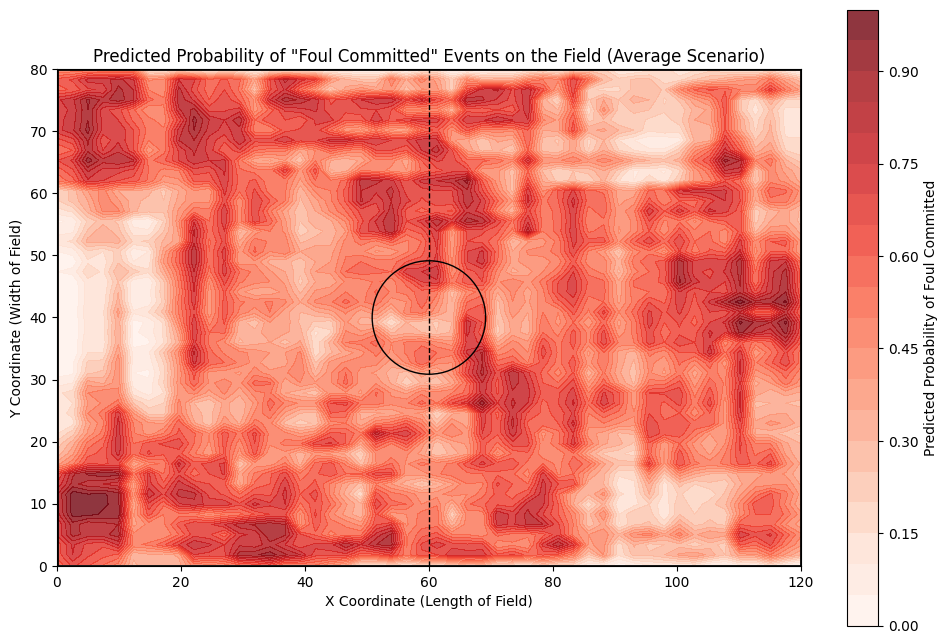


Feature Importances:


,Feature,Importance
1,y,0.304166
0,x,0.299722
2,minute,0.207819
3,under_pressure,0.101053
4,counterpress,0.087240


/tmp/ipykernel_11186/1109230974.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


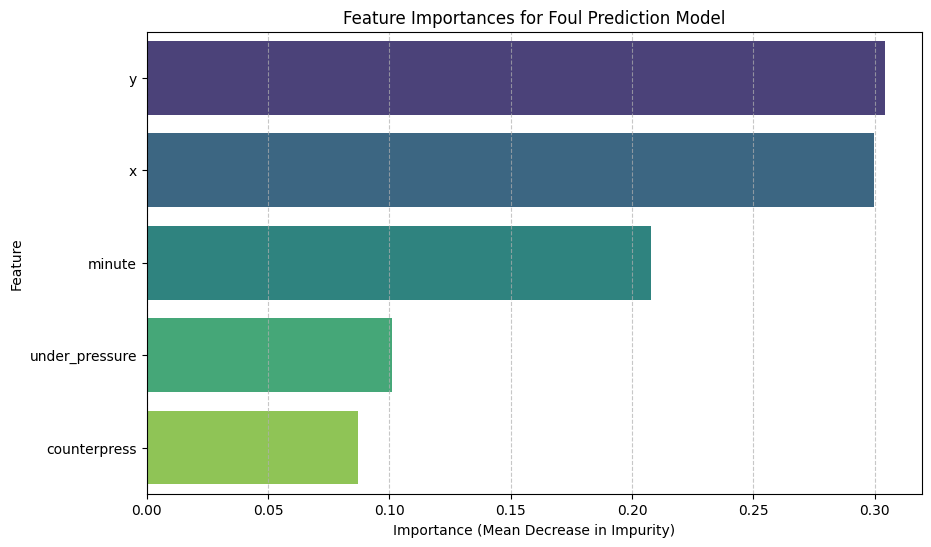

In [20]:
# --- Visualizing the Predicted Probabilities (Static Version) ---
# Create a grid for prediction
x_grid = np.linspace(X['x'].min(), X['x'].max(), 50)
y_grid = np.linspace(X['y'].min(), X['y'].max(), 50)
xx, yy = np.meshgrid(x_grid, y_grid)

# Prepare input for prediction using average values for non-spatial features
mean_minute = X['minute'].mean()
mean_under_pressure = X['under_pressure'].mean()
mean_counterpress = X['counterpress'].mean()

grid_predictions_input = pd.DataFrame({
    'x': xx.ravel(),
    'y': yy.ravel(),
    'minute': mean_minute,
    'under_pressure': mean_under_pressure,
    'counterpress': mean_counterpress
})

# Predict probabilities across the grid
Z = model.predict_proba(grid_predictions_input[features])[:, 1]
Z = Z.reshape(xx.shape)

# Plot the probability heatmap on the field
plt.figure(figsize=(12, 8))
contour = plt.contourf(xx, yy, Z, levels=20, cmap='Reds', alpha=0.8)
plt.colorbar(contour, label='Predicted Probability of Foul Committed')

# Simulate a football field outline
plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
plt.axvline(x=120, color='black', linestyle='-', linewidth=2)
plt.axhline(y=0, color='black', linestyle='-', linewidth=2)
plt.axhline(y=80, color='black', linestyle='-', linewidth=2)
plt.axvline(x=60, color='black', linestyle='--', linewidth=1)
center_circle = plt.Circle((60, 40), 9.15, color='black', fill=False)
plt.gca().add_patch(center_circle)

plt.xlim(0, 120)
plt.ylim(0, 80)
plt.title('Predicted Probability of "Foul Committed" Events on the Field (Average Scenario)')
plt.xlabel('X Coordinate (Length of Field)')
plt.ylabel('Y Coordinate (Width of Field)')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(False)
plt.show()

# --- Feature Importance Analysis ---
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
display(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importances for Foul Prediction Model')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
